<a href="https://colab.research.google.com/github/maheshkumar30/DataScience/blob/main/Fully_Connected_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix


# **LOAD FASHION MNIST DATASET**

In [2]:
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Dataset Shape
print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


# **CLASS LABELS**

In [3]:
fashion_classes = [
    'T-shirt/Top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle Boot'
]


# **DATA VISUALIZATION**

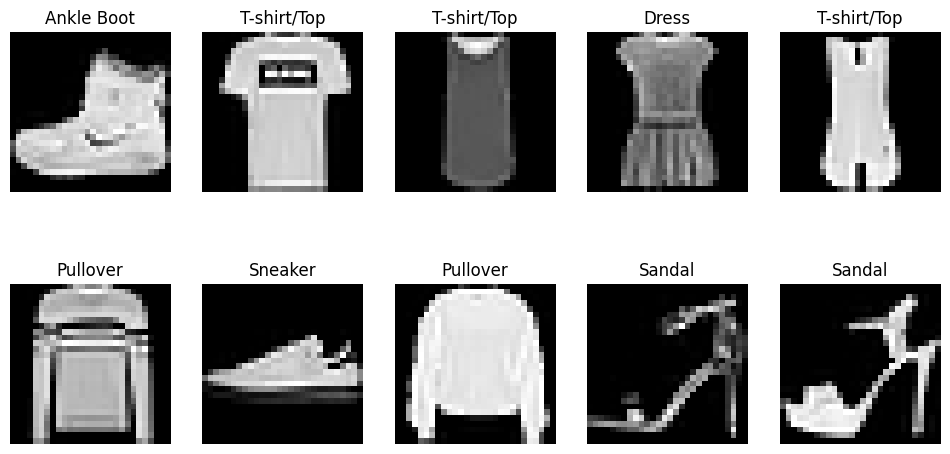

In [4]:
plt.figure(figsize=(12,6))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_train[i], cmap='gray')

    plt.title(fashion_classes[y_train[i]])

    plt.axis('off')

plt.show()

# **VISUALIZE CLASS DISTRIBUTION**

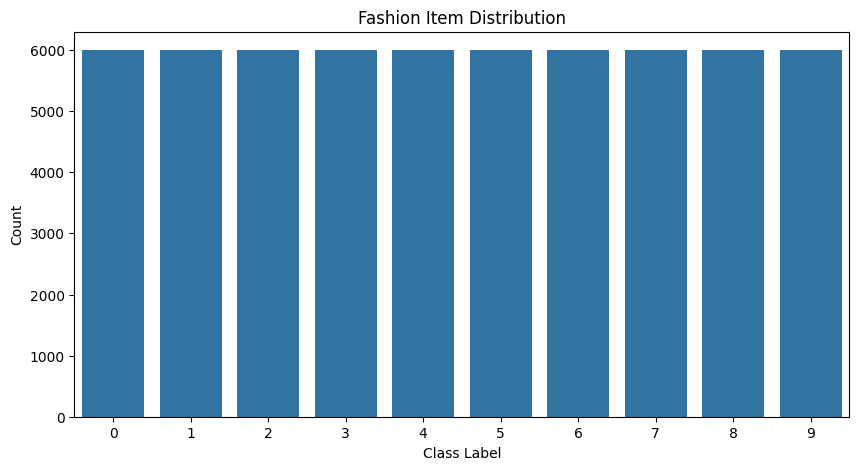

In [5]:
plt.figure(figsize=(10,5))

sns.countplot(x=y_train)

plt.title("Fashion Item Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")

plt.show()

# **DATA PREPROCESSING**

In [6]:
# Normalize Pixel Values
X_train = X_train / 255.0
X_test = X_test / 255.0

# One-Hot Encoding
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("One Hot Encoded Label Example:")
print(y_train_cat[0])

One Hot Encoded Label Example:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


# **BUILD FULLY CONNECTED NEURAL NETWORK**

In [7]:
model = Sequential()

# Input Layer
model.add(Flatten(input_shape=(28,28)))

# Hidden Layer 1
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))

# Hidden Layer 2
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

# Hidden Layer 3
model.add(Dense(64, activation='relu'))

# Output Layer
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# **COMPILE MODEL**

In [8]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Display Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

# **TRAIN MODEL**

In [9]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=15,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.6577 - loss: 0.9586 - val_accuracy: 0.7985 - val_loss: 0.5759
Epoch 2/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7831 - loss: 0.6135 - val_accuracy: 0.8278 - val_loss: 0.4864
Epoch 3/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8109 - loss: 0.5339 - val_accuracy: 0.8366 - val_loss: 0.4576
Epoch 4/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8264 - loss: 0.4910 - val_accuracy: 0.8444 - val_loss: 0.4288
Epoch 5/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8365 - loss: 0.4621 - val_accuracy: 0.8521 - val_loss: 0.4017
Epoch 6/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8417 - loss: 0.4420 - val_accuracy: 0.8607 - val_loss: 0.3880
Epoch 7/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8465 - loss: 0.4279 - val_accuracy: 0.8646 - val_loss: 0.3796
Epoch 8/15
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8534 - loss: 0.4125 -

# **EVALUATE MODEL**

In [10]:
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat)

print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8697 - loss: 0.3603

Test Loss: 0.3603383004665375
Test Accuracy: 0.869700014591217


# **VISUALIZE TRAINING ACCURACY**

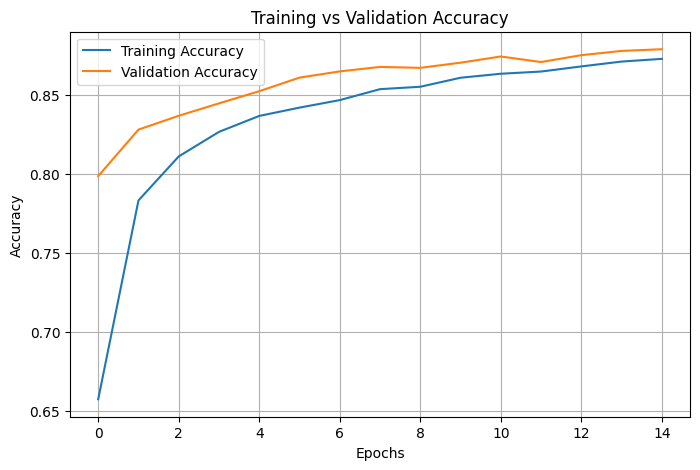

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

# **VISUALIZE TRAINING LOSS**

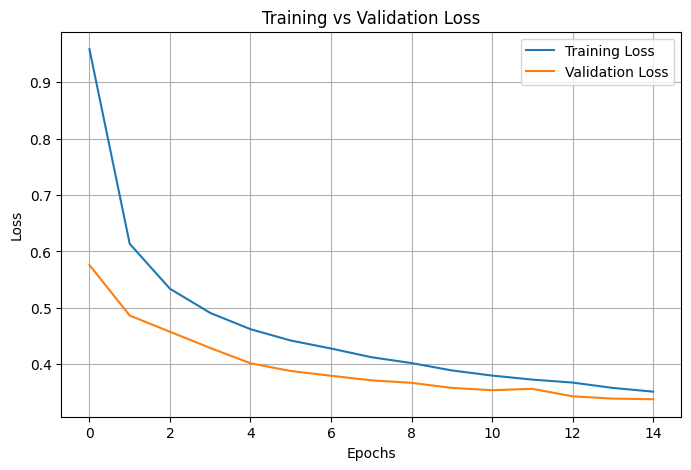

In [12]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

# **MAKE PREDICTIONS**

In [13]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


# **DISPLAY SAMPLE PREDICTIONS**

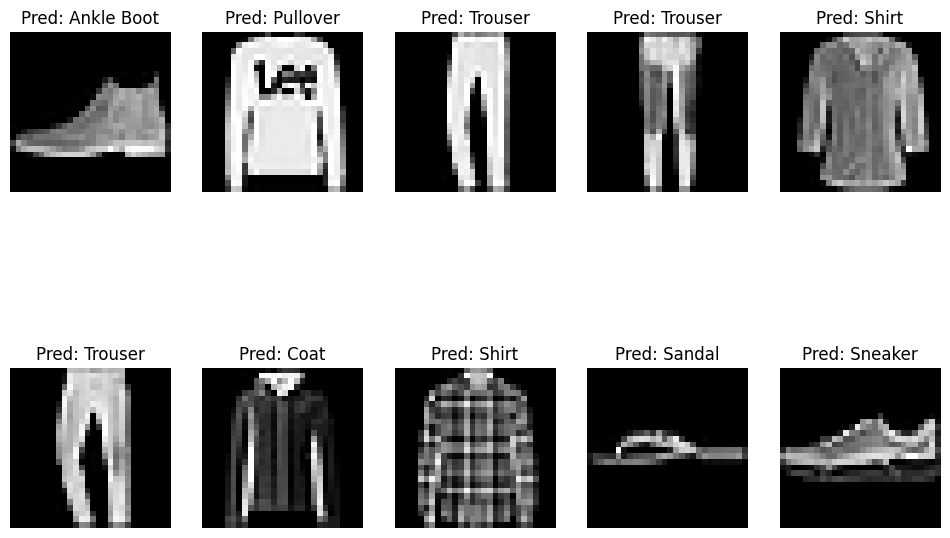

In [14]:
plt.figure(figsize=(12,8))

for i in range(10):

    plt.subplot(2,5,i+1)

    plt.imshow(X_test[i], cmap='gray')

    plt.title(f"Pred: {fashion_classes[predicted_labels[i]]}")

    plt.axis('off')

plt.show()

# **CLASSIFICATION REPORT**

In [15]:
print("\nClassification Report:\n")

print(classification_report(y_test, predicted_labels))



Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.80      0.81      1000
           1       0.99      0.96      0.97      1000
           2       0.76      0.81      0.79      1000
           3       0.85      0.90      0.87      1000
           4       0.77      0.81      0.79      1000
           5       0.97      0.94      0.95      1000
           6       0.69      0.61      0.65      1000
           7       0.91      0.96      0.93      1000
           8       0.96      0.97      0.96      1000
           9       0.97      0.93      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



# **CONFUSION MATRIX**

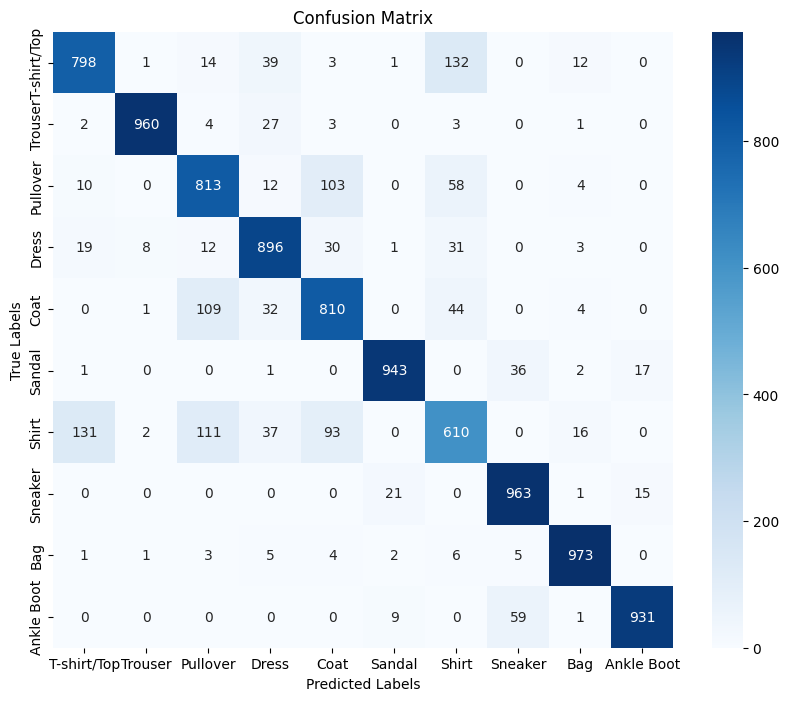

In [16]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=fashion_classes,
    yticklabels=fashion_classes
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")

plt.show()

# **SINGLE IMAGE PREDICTION**

In [17]:
sample_image = X_test[0]

sample_image = sample_image.reshape(1,28,28)

prediction = model.predict(sample_image)

predicted_class = np.argmax(prediction)

print("\nPredicted Fashion Item:",
      fashion_classes[predicted_class])

print("Actual Fashion Item:",
      fashion_classes[y_test[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step

Predicted Fashion Item: Ankle Boot
Actual Fashion Item: Ankle Boot


# **SAVE MODEL**

In [18]:
model.save("fashion_mnist_fcnn_model.h5")

print("\nModel Saved Successfully!")


Model Saved Successfully!


# **FINAL ANALYSIS**

In [19]:
print("\nPROJECT ANALYSIS")

print("1. FCNN successfully classifies fashion items.")
print("2. ReLU activation improves hidden layer learning.")
print("3. Softmax activation converts outputs into probabilities.")
print("4. Dropout helps reduce overfitting.")
print("5. Validation accuracy helps monitor generalization.")


PROJECT ANALYSIS
1. FCNN successfully classifies fashion items.
2. ReLU activation improves hidden layer learning.
3. Softmax activation converts outputs into probabilities.
4. Dropout helps reduce overfitting.
5. Validation accuracy helps monitor generalization.
